# **Problem Statement**

## **Business Context**

Workplace safety in hazardous environments like construction sites and industrial plants is crucial to prevent accidents and injuries. One of the most important safety measures is ensuring workers wear safety helmets, which protect against head injuries from falling objects and machinery. Non-compliance with helmet regulations increases the risk of serious injuries or fatalities, making effective monitoring essential, especially in large-scale operations where manual oversight is prone to errors and inefficiency.

To overcome these challenges, SafeGuard Corp plans to develop an automated image analysis system capable of detecting whether workers are wearing safety helmets. This system will improve safety enforcement, ensuring compliance and reducing the risk of head injuries. By automating helmet monitoring, SafeGuard aims to enhance efficiency, scalability, and accuracy, ultimately fostering a safer work environment while minimizing human error in safety oversight.

## **Objective**

As a data scientist at SafeGuard Corp, you are tasked with developing an image classification model that classifies images into one of two categories:
- **With Helmet:** Workers wearing safety helmets.
- **Without Helmet:** Workers not wearing safety helmets.

## **Data Description**

The dataset consists of **631 images**, equally divided into two categories:

- **With Helmet:** 311 images showing workers wearing helmets.
- **Without Helmet:** 320 images showing workers not wearing helmets.

**Dataset Characteristics:**
- **Variations in Conditions:** Images include diverse environments such as construction sites, factories, and industrial settings, with variations in lighting, angles, and worker postures to simulate real-world conditions.
- **Worker Activities:** Workers are depicted in different actions such as standing, using tools, or moving, ensuring robust model learning for various scenarios.

# **Installing and Importing the Necessary Libraries**

In [1]:
!pip3.11 install tensorflow[and-cuda] numpy==1.25.2 -q


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: /usr/bin/python3.11 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: /usr/bin/python3.11 -m pip install --upgrade pip


In [2]:
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(tf.__version__)

2025-11-02 15:08:13.451073: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-02 15:08:13.452055: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-02 15:08:13.455328: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-02 15:08:13.463194: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-02 15:08:13.475616: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been 

Num GPUs Available: 0
2.17.1


2025-11-02 15:08:15.475403: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [3]:
import os
import random
import numpy as np                                                                               # Importing numpy for Matrix Operations
import pandas as pd
import seaborn as sns
import matplotlib.image as mpimg                                                                              # Importing pandas to read CSV files
import matplotlib.pyplot as plt                                                                  # Importting matplotlib for Plotting and visualizing images
import math                                                                                      # Importing math module to perform mathematical operations
import cv2
import collections


# Tensorflow modules
import keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator                              # Importing the ImageDataGenerator for data augmentation
from tensorflow.keras.models import Sequential                                                   # Importing the sequential module to define a sequential model
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization # Defining all the layers to build our CNN Model
from tensorflow.keras.optimizers import Adam,SGD                                                 # Importing the optimizers which can be used in our model
from sklearn import preprocessing                                                                # Importing the preprocessing module to preprocess the data
from sklearn.model_selection import train_test_split                                             # Importing train_test_split function to split the data into train and test
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Model
from keras.applications.vgg16 import VGG16        
from sklearn.preprocessing import LabelEncoder                                       # Importing confusion_matrix to plot the confusion matrix

from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau



# Display images using OpenCV
# Compatibility helper: prefer Colab's cv2_imshow when available, otherwise fallback to matplotlib/cv2.
def cv2_imshow_compat(img, title=None):
    try:
        from google.colab.patches import cv2_imshow as _cv2_imshow
        _cv2_imshow(img)
        return
    except Exception:
        pass
    # Fallback to matplotlib for Jupyter notebooks (convert BGR->RGB for color images)
    try:
        import matplotlib.pyplot as plt
        if img is None:
            return
        if hasattr(img, 'shape') and len(img.shape) == 3 and img.shape[2] == 3:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        else:
            img_rgb = img
        plt.figure(figsize=(6,6))
        cmap = 'gray' if (hasattr(img_rgb, 'ndim') and img_rgb.ndim == 2) else None
        plt.imshow(img_rgb, cmap=cmap)
        if title:
            plt.title(title)
        plt.axis('off')
        plt.show()
    except Exception as e:
        # Last resort: try cv2.imshow (may not work in headless environments)
        try:
            cv2.imshow(title or 'Image', img)
            cv2.waitKey(0)
            cv2.destroyAllWindows()
        except Exception:
            print('Unable to display image in this environment:', e)

#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
from sklearn.metrics import mean_squared_error as mse                                                 # Importing cv2_imshow from google.patches to display images

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
tf.keras.utils.set_random_seed(812)

# **Data Overview**


### Loading the data

In [5]:
images_proj = np.load('/root/ashiravi/images_proj.npy')
Labels_proj = pd.read_csv('/root/ashiravi/Labels_proj.csv')

#checking the shapes of loaded data
print(images_proj.shape)
print(Labels_proj.shape)

(631, 200, 200, 3)
(631, 1)


# **Exploratory Data Analysis**

### Plot random images from each of the classes and print their corresponding labels and Checking for class imbalance

Images: 631, Labels: 631, using label column: "Label"

Class distribution:
0    320
1    311


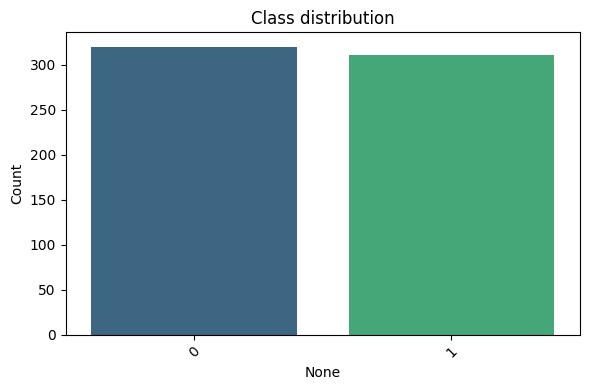

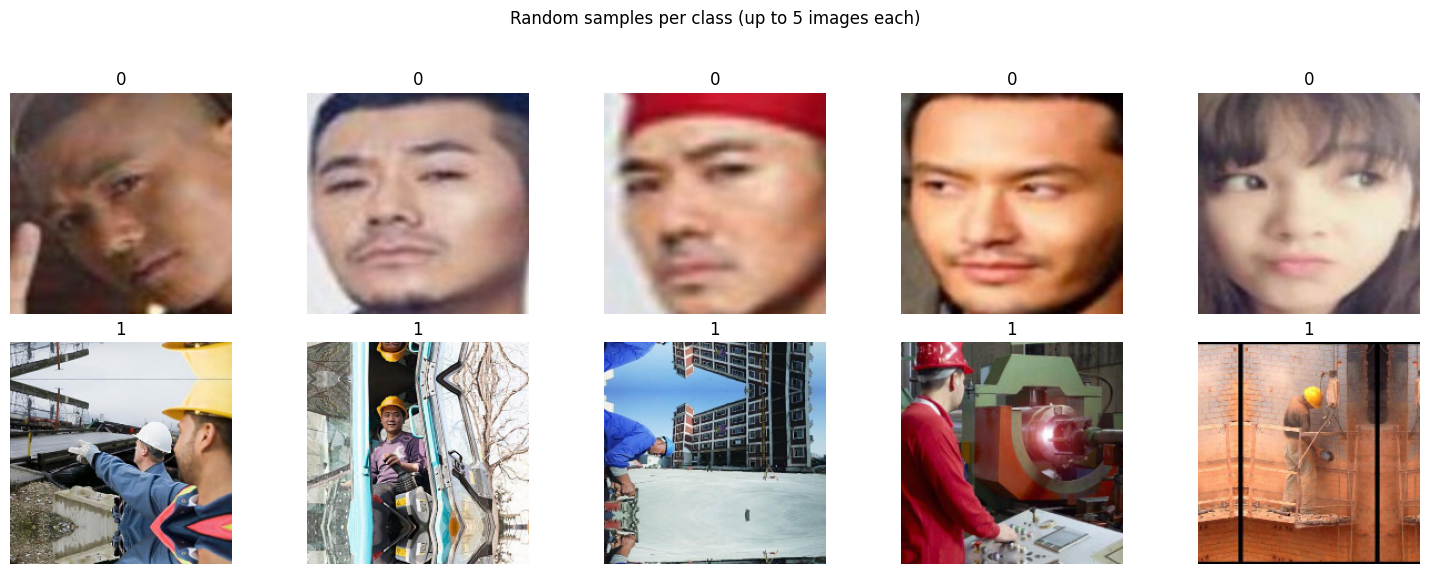


Image shape summary (shape:count) — top 10:
(200, 200, 3): 631

Imbalance ratio (max/min): 1.03


In [6]:
# 1) Ensure the data objects exist
try:
    imgs = images_proj
    labels_df = Labels_proj
except NameError as e:
    raise NameError('images_proj or Labels_proj not found. Run the data loading cell first.') from e

# 2) Robustly find the label column
cols_lower = [c.lower() for c in labels_df.columns]
possible_cols = ['label', 'labels', 'class', 'target', 'y']
label_col = None
for pc in possible_cols:
    if pc in cols_lower:
        label_col = labels_df.columns[cols_lower.index(pc)]
        break
if label_col is None:
    label_col = labels_df.columns[0]  # fall back to first column

labels = labels_df[label_col].astype(str).to_numpy().reshape(-1)

# 3) Basic consistency checks
n_images = imgs.shape[0] if hasattr(imgs, 'shape') else len(imgs)
n_labels = labels.shape[0]
print(f'Images: {n_images}, Labels: {n_labels}, using label column: "{label_col}"')
if n_images != n_labels:
    print('Warning: number of images and labels differ. Proceeding with the minimum of the two.')
    m = min(n_images, n_labels)
    imgs = imgs[:m]
    labels = labels[:m]

# 4) Class distribution and imbalance check
class_counts = pd.Series(labels).value_counts().sort_index()
print('\nClass distribution:')
print(class_counts.to_string())

# Visualize class distribution
plt.figure(figsize=(6,4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.ylabel('Count')
plt.title('Class distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 5) Plot random samples per class (up to `max_per_class` images each)
max_per_class = 5
classes = class_counts.index.tolist()
rows = len(classes)
cols = max_per_class
fig, axes = plt.subplots(rows, cols, figsize=(cols*3, max(3, rows*3)))
if rows == 1:
    axes = axes.reshape(1, -1)

for i, cls in enumerate(classes):
    idxs = np.where(labels == cls)[0].tolist()
    if len(idxs) == 0:
        for j in range(cols):
            axes[i, j].axis('off')
        continue
    sampled = random.sample(idxs, min(len(idxs), max_per_class))
    for j in range(cols):
        ax = axes[i, j]
        ax.axis('off')
        if j < len(sampled):
            img = imgs[sampled[j]]
            img = np.asarray(img)
            # convert BGR->RGB if image looks like OpenCV BGR format
            try:
                if img.ndim == 3 and img.shape[2] == 3:
                    img_disp = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                else:
                    img_disp = img
            except Exception:
                img_disp = img
            cmap = 'gray' if (img_disp.ndim == 2) else None
            ax.imshow(img_disp, cmap=cmap)
            ax.set_title(str(cls))
        else:
            ax.set_visible(False)
plt.suptitle(f'Random samples per class (up to {max_per_class} images each)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 6) Helpful numeric summaries and observations
unique_shapes = collections.Counter([tuple(np.asarray(im).shape) for im in imgs])
print('\nImage shape summary (shape:count) — top 10:')
for s, c in unique_shapes.most_common(10):
    print(f'{s}: {c}')

min_c = class_counts.min()
max_c = class_counts.max()
imbalance_ratio = (max_c / min_c) if min_c > 0 else float('inf')
print(f'\nImbalance ratio (max/min): {imbalance_ratio:.2f}')


##### Observation
- Number of classes: 2
- Classes are roughly balanced.
- Total images used: 631
- Most common image shape: (200, 200, 3) (count=631)

# **Data Preprocessing**

## Converting images to grayscale

Using 631 images and labels. Label column = "Label"


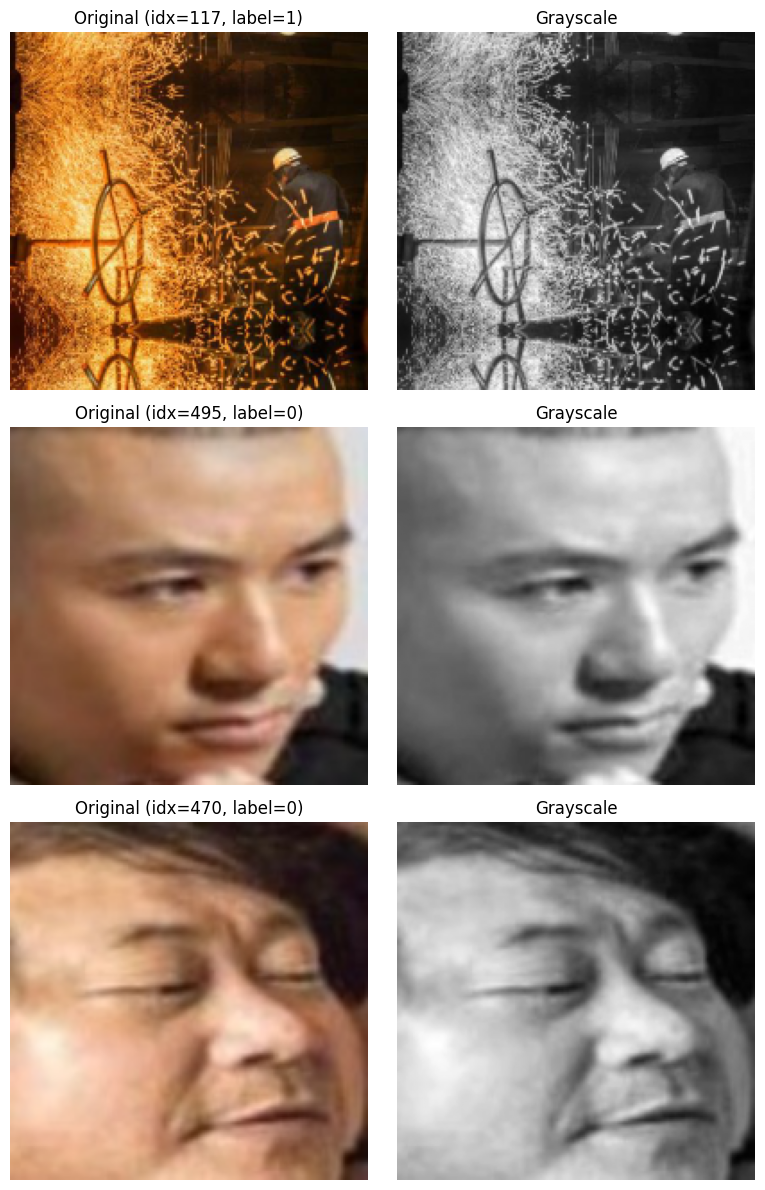

Converted to grayscale: X_gray.shape = (631, 200, 200, 1)


In [7]:
# 1) Basic checks
try:
    X = images_proj
    y_df = Labels_proj
except NameError as e:
    raise NameError('images_proj or Labels_proj not found. Run the data loading cell first.') from e

# robust label column detection (reuse logic from EDA)
cols_lower = [c.lower() for c in y_df.columns]
possible_cols = ['label', 'labels', 'class', 'target', 'y']
label_col = None
for pc in possible_cols:
    if pc in cols_lower:
        label_col = y_df.columns[cols_lower.index(pc)]
        break
if label_col is None:
    label_col = y_df.columns[0]

y = y_df[label_col].astype(str).to_numpy().reshape(-1)

n = min(len(X), len(y))
if len(X) != len(y):
    print(f'Warning: images ({len(X)}) and labels ({len(y)}) lengths differ. Truncating to {n}.')
    X = X[:n]
    y = y[:n]

print(f'Using {len(X)} images and labels. Label column = "{label_col}"')

# 2) Show a few before/after samples
def to_display(img):
    img = np.asarray(img)
    # if colored image, try convert BGR->RGB for plotting (handles OpenCV-arrays)
    if img.ndim == 3 and img.shape[2] == 3:
        try:
            return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        except Exception:
            return img
    return img

sample_idxs = np.random.choice(len(X), size=min(3, len(X)), replace=False)
fig, axes = plt.subplots(3, 2, figsize=(8, 12))
for i, idx in enumerate(sample_idxs):
    orig = np.asarray(X[idx])
    disp = to_display(orig)
    # convert to grayscale
    if orig.ndim == 3 and orig.shape[2] == 3:
        gray = cv2.cvtColor(orig, cv2.COLOR_BGR2GRAY)
    elif orig.ndim == 2:
        gray = orig
    else:
        # fallback: average channels
        gray = np.mean(orig, axis=2).astype(orig.dtype)

    axes[i, 0].imshow(disp, cmap=None)
    axes[i, 0].set_title(f'Original (idx={idx}, label={y[idx]})')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(gray, cmap='gray')
    axes[i, 1].set_title('Grayscale')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

# 3) Convert entire dataset to grayscale and ensure consistent shape (H,W,1)
X_gray = []
for im in X:
    im = np.asarray(im)
    if im.ndim == 3 and im.shape[2] == 3:
        g = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
    elif im.ndim == 2:
        g = im
    else:
        # if unexpected channel dim, average across channels
        g = np.mean(im, axis=2).astype(im.dtype)
    # ensure dtype is uint8 or float
    X_gray.append(g)

X_gray = np.stack(X_gray, axis=0)
# expand channel axis
X_gray = X_gray[..., np.newaxis]
print(f'Converted to grayscale: X_gray.shape = {X_gray.shape}')




### Splitting the dataset



In [8]:
# Split into train / val / test: 70% train, 15% val, 15% test
try:
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_gray, y, test_size=0.30, random_state=42, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
except ValueError as e:
    print('Stratified split failed, falling back to non-stratified split:', e)
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_gray, y, test_size=0.30, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42)

print('Split sizes:')
print(f'  Train: {X_train.shape}, {len(y_train)}')
print(f'  Val:   {X_val.shape}, {len(y_val)}')
print(f'  Test:  {X_test.shape}, {len(y_test)}')

Split sizes:
  Train: (441, 200, 200, 1), 441
  Val:   (95, 200, 200, 1), 95
  Test:  (95, 200, 200, 1), 95


### Data Normalization

In [9]:
# Normalization: scale pixels to [0,1] and convert to float32
X_train = X_train.astype('float32') / 255.0
X_val = X_val.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print('\nAfter normalization:')
print(f'  Train dtype/ range: {X_train.dtype}, min={X_train.min():.4f}, max={X_train.max():.4f}')

# Save processed arrays into the notebook namespace for later cells
processed = {
    'X_train': X_train, 'y_train': y_train,
    'X_val': X_val, 'y_val': y_val,
    'X_test': X_test, 'y_test': y_test
}

print('\nPreprocessing completed. Use processed["X_train"] / processed["y_train"] etc. in subsequent cells.')



After normalization:
  Train dtype/ range: float32, min=0.0000, max=1.0000

Preprocessing completed. Use processed["X_train"] / processed["y_train"] etc. in subsequent cells.


# **Model Building**

### Model Evaluation Criterion

## Utility Functions

In [10]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    
    # Get predictions and convert to class indices
    predictions = model.predict(predictors)
    if predictions.shape[-1] > 1:  # multi-class case
        pred = np.argmax(predictions, axis=-1)
    else:  # binary case
        pred = (predictions > 0.5).reshape(-1)

    # Ensure target is in the right format
    target = np.array(target)
    if target.ndim > 1:
        target = target.reshape(-1)

    # Compute metrics
    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='weighted')  # to compute Recall
    precision = precision_score(target, pred, average='weighted')  # to compute Precision
    f1 = f1_score(target, pred, average='weighted')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame({
        "Accuracy": acc,
        "Recall": recall,
        "Precision": precision,
        "F1 Score": f1,
    }, index=[0])

    return df_perf

In [11]:
def plot_confusion_matrix(model, predictors, target, ml=False):
    """
    Function to plot the confusion matrix

    model: classifier
    predictors: independent variables
    target: dependent variable
    ml: To specify if the model used is an sklearn ML model or not (True means ML model)
    """
    
    # Get predictions and convert to class indices
    predictions = model.predict(predictors)
    if predictions.shape[-1] > 1:  # multi-class case
        pred = np.argmax(predictions, axis=-1)
    else:  # binary case
        pred = (predictions > 0.5).reshape(-1)

    # Ensure target is in the right format
    target = np.array(target)
    if target.ndim > 1:
        target = target.reshape(-1)

    # Plotting the Confusion Matrix
    cm = confusion_matrix(target, pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        linewidths=.4,
        fmt="d",
        square=True,
        cmap='Blues'
    )
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

## Model 1: Simple Convolutional Neural Network (CNN)

In [12]:
# - Define a small CNN suitable for grayscale images (input shape inferred from processed data)
# - Configure optimizer, loss, metrics and training parameters
# - Train the model and save history for later visualization

# Check that preprocessing has been run and processed dict exists
if 'processed' not in globals():
    raise RuntimeError('Preprocessed data not found. Run the preprocessing cell first.')

X_train = processed['X_train']
y_train = np.array(processed['y_train'])
X_val = processed['X_val']
y_val = np.array(processed['y_val'])
X_test = processed['X_test']
y_test = np.array(processed['y_test'])

# Encode string labels to integers
le = LabelEncoder()
le.fit(np.concatenate([y_train, y_val, y_test]))

y_train_enc = le.transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)

num_classes = len(le.classes_)
input_shape = X_train.shape[1:]
print(f'Input shape: {input_shape}, Num classes: {num_classes}')

# Build a simple CNN
def build_simple_cnn(input_shape, num_classes):
    model = Sequential([
        # First Convolutional Block
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D((2,2)),
        
        # Second Convolutional Block
        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),
        
        # Third Convolutional Block
        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),
        
        # Flatten layer to connect to Dense layers
        Flatten(),
        
        # Dense layers with dropout for regularization
        Dense(128, activation='relu'),
        Dropout(0.4),
        Dense(num_classes, activation='softmax')
    ])
    return model

# Create and compile the model
model_cnn = build_simple_cnn(input_shape, num_classes)
model_cnn.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
model_cnn.summary()

# Training configuration
epochs = 10
batch_size = 32

# Train the model
print("\nTraining the model...")
history = model_cnn.fit(
    X_train, y_train_enc,
    validation_data=(X_val, y_val_enc),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

# Save useful objects for visualization
trained_models = globals().get('trained_models', {})
trained_models['cnn_model_1'] = model_cnn
trained_models['cnn_history_1'] = history
trained_models['label_encoder'] = le
globals()['trained_models'] = trained_models

print('\nTraining completed. Model saved for visualization.')

Input shape: (200, 200, 1), Num classes: 2


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 200, 200, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 200, 200, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 100, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 50, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 80000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    10,240,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,333,954 (39.42 MB)

 Trainable params: 10,333,506 (39.42 MB)

 Non-trainable params: 448 (1.75 KB)


Training the model...
Epoch 1/10
Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 442ms/step - accuracy: 0.9342 - loss: 0.7828 - val_accuracy: 0.5053 - val_loss: 39.3963
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 442ms/step - accuracy: 0.9342 - loss: 0.7828 - val_accuracy: 0.5053 - val_loss: 39.3963
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 429ms/step - accuracy: 0.9819 - loss: 1.0489 - val_accuracy: 0.5053 - val_loss: 97.9347
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 429ms/step - accuracy: 0.9819 - loss: 1.0489 - val_accuracy: 0.5053 - val_loss: 97.9347
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 429ms/step - accuracy: 0.9864 - loss: 1.1897 - val_accuracy: 0.5053 - val_loss: 141.0986
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 429ms/step - accuracy: 0.9864 - loss: 1.1897 - val_accuracy: 0.5053 - val_loss: 141.0986
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 426ms/step - accuracy: 0.9977 - loss: 0.2214 - val_accuracy: 0.5053 - val_loss: 175.1513
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 426ms/step - accura

### Vizualizing the predictions

1. Model Performance Metrics
--------------------------------------------------
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step

Model Performance Metrics:
   Accuracy    Recall  Precision  F1 Score
0  0.505263  0.505263   0.255291  0.339198

2. Confusion Matrix
--------------------------------------------------

Model Performance Metrics:
   Accuracy    Recall  Precision  F1 Score
0  0.505263  0.505263   0.255291  0.339198

2. Confusion Matrix
--------------------------------------------------
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


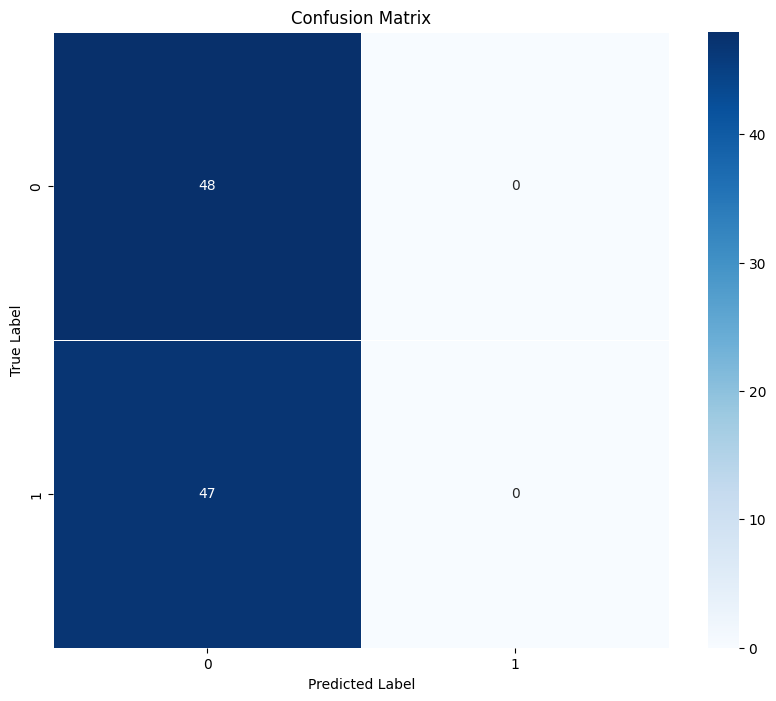


3. Training History
--------------------------------------------------


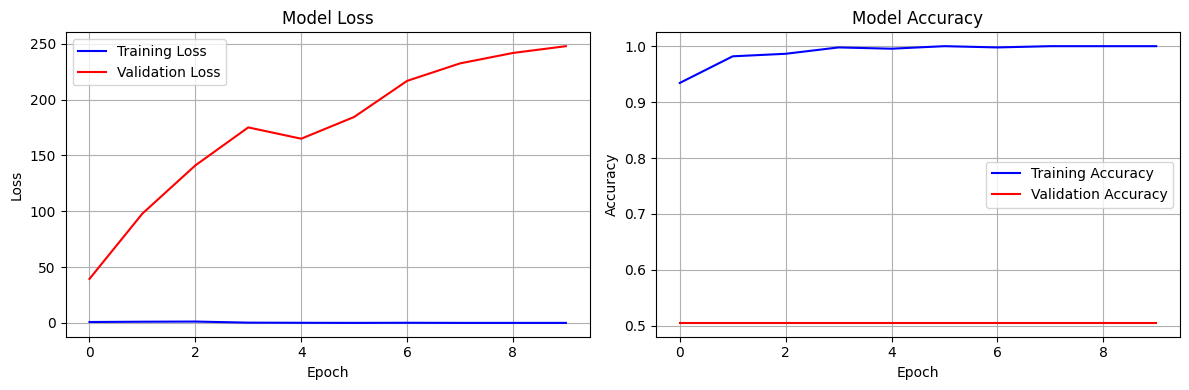


4. Sample Predictions
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


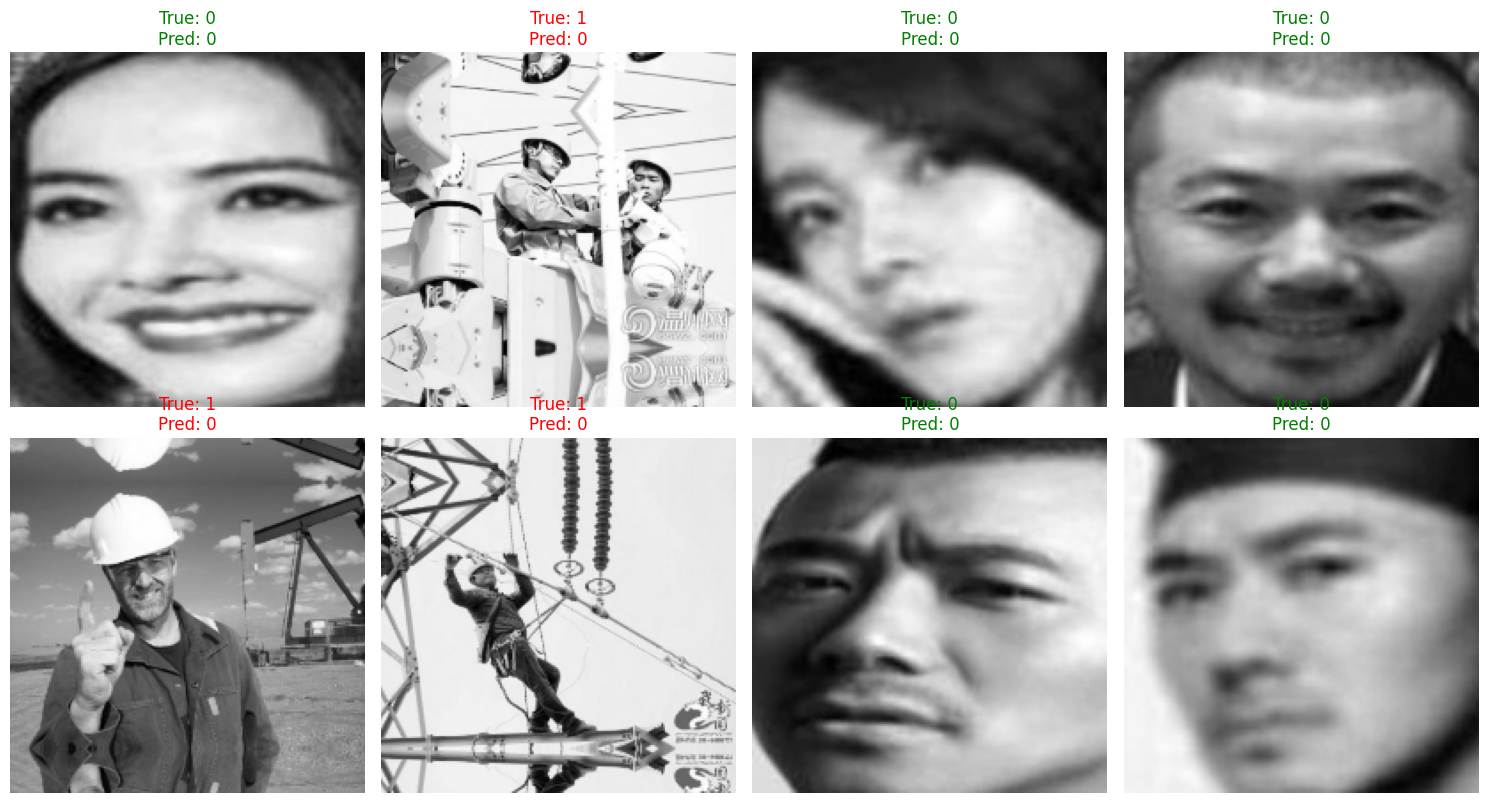


5. Model Performance Analysis
--------------------------------------------------
Final Training Accuracy: 1.0000
Final Validation Accuracy: 0.5053
Final Training Loss: 0.0000
Final Validation Loss: 247.9447
- Model training plateaued in final epochs


In [13]:
# Visualization and Performance Analysis of Basic CNN Model
# This cell uses our utility functions to analyze model performance

# Verify model exists
if 'trained_models' not in globals() or 'cnn_model_1' not in trained_models:
    raise RuntimeError('CNN model not found. Run the Model 1 training cell first.')

model = trained_models['cnn_model_1']
history = trained_models['cnn_history_1']
le = trained_models['label_encoder']

# 1. Model Performance Metrics using our utility function
print("1. Model Performance Metrics")
print("-" * 50)
df_performance = model_performance_classification(model, X_test, y_test_enc)
print("\nModel Performance Metrics:")
print(df_performance)

# 2. Plot Confusion Matrix using our utility function
print("\n2. Confusion Matrix")
print("-" * 50)
plot_confusion_matrix(model, X_test, y_test_enc)

# 3. Training History Visualization
print("\n3. Training History")
print("-" * 50)
plt.figure(figsize=(12,4))

# Loss plot
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy plot
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 4. Sample Predictions
print("\n4. Sample Predictions")
print("-" * 50)
n_samples = 8
sample_indices = np.random.choice(len(X_test), n_samples)
predictions = model.predict(X_test[sample_indices])
pred_classes = np.argmax(predictions, axis=1)
true_classes = y_test_enc[sample_indices]

fig, axes = plt.subplots(2, 4, figsize=(15, 8))
for i, (ax, idx) in enumerate(zip(axes.flat, sample_indices)):
    img = X_test[idx].squeeze()
    ax.imshow(img, cmap='gray')
    pred_label = le.inverse_transform([pred_classes[i]])[0]
    true_label = le.inverse_transform([true_classes[i]])[0]
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(f'True: {true_label}\nPred: {pred_label}', color=color)
    ax.axis('off')
plt.tight_layout()
plt.show()

# 5. Performance Analysis
print("\n5. Model Performance Analysis")
print("-" * 50)

# Get final metrics
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")

# Learning dynamics
acc_trend = np.diff(history.history['val_accuracy'])
if np.all(acc_trend[-3:] < 0.001):  # Check if accuracy plateaued
    print("- Model training plateaued in final epochs")

Model Behavior Analysis:
- Model shows signs of overfitting (validation loss significantly higher)
- Model may need improvement (accuracy <80%)
- Model training plateaued in final epochs

## Model 2: (VGG-16 (Base))

In [14]:
# Using VGG16 base model

# Verify preprocessed data exists
if 'processed' not in globals():
    raise RuntimeError('Preprocessed data not found. Run the preprocessing cell first.')

# Get preprocessed data
X_train = processed['X_train']
y_train = np.array(processed['y_train'])
X_val = processed['X_val']
y_val = np.array(processed['y_val'])
X_test = processed['X_test']
y_test = np.array(processed['y_test'])

# Convert grayscale to 3-channel (VGG16 expects RGB input)
def expand_to_3channel(X):
    """Convert single-channel grayscale to 3-channel by repeating the channel"""
    return np.repeat(X, 3, axis=-1)

X_train_3ch = expand_to_3channel(X_train)
X_val_3ch = expand_to_3channel(X_val)
X_test_3ch = expand_to_3channel(X_test)

print("Data shapes after channel expansion:")
print(f"Training: {X_train_3ch.shape}")
print(f"Validation: {X_val_3ch.shape}")
print(f"Test: {X_test_3ch.shape}")

# Prepare labels
le = LabelEncoder()
le.fit(np.concatenate([y_train, y_val, y_test]))
y_train_enc = le.transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)
num_classes = len(le.classes_)

# Create VGG16 base model
input_shape = X_train_3ch.shape[1:]  # (height, width, channels)
base_model = VGG16(
    weights='imagenet',  # Use pretrained ImageNet weights
    include_top=False,   # Exclude final classification layers
    input_shape=input_shape
)

# Freeze VGG16 layers (transfer learning)
base_model.trainable = False

# Build full model with custom classification head
model_vgg = Sequential([
    # VGG16 base
    base_model,
    
    # Classification head
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

# Compile model
model_vgg.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model summary
model_vgg.summary()

# Training configuration
epochs = 20
batch_size = 32

# Add callbacks for better training
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

print("\nTraining VGG-16 model...")
history_vgg = model_vgg.fit(
    X_train_3ch, y_train_enc,
    validation_data=(X_val_3ch, y_val_enc),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=callbacks,
    verbose=1
)

# Save model artifacts for visualization
trained_models = globals().get('trained_models', {})
trained_models['vgg16_model'] = model_vgg
trained_models['vgg16_history'] = history_vgg
trained_models['vgg16_label_encoder'] = le
globals()['trained_models'] = trained_models

print('\nVGG-16 model training completed. Model saved for visualization.')

Data shapes after channel expansion:
Training: (441, 200, 200, 3)
Validation: (95, 200, 200, 3)
Test: (95, 200, 200, 3)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,530 (56.64 MB)

 Trainable params: 131,842 (515.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)


Training VGG-16 model...
Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 341ms/step - accuracy: 0.6259 - loss: 0.6650 - val_accuracy: 1.0000 - val_loss: 0.5514 - learning_rate: 1.0000e-04
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 341ms/step - accuracy: 0.6259 - loss: 0.6650 - val_accuracy: 1.0000 - val_loss: 0.5514 - learning_rate: 1.0000e-04
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 366ms/step - accuracy: 0.6803 - loss: 0.5760 - val_accuracy: 1.0000 - val_loss: 0.4574 - learning_rate: 1.0000e-04
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 366ms/step - accuracy: 0.6803 - loss: 0.5760 - val_accuracy: 1.0000 - val_loss: 0.4574 - learning_rate: 1.0000e-04
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 333ms/step - accuracy: 0.8027 - loss: 0.4731 - val_accuracy: 1.0000 - val_loss: 0.3851 - learning_rate: 1.0000e-04
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 333ms/step - accuracy: 0.8027 - loss: 0.4731 - val_accuracy: 1.0000 - val_loss: 0.3851 - learning_rate: 1.0000e-04
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 

### Visualizing the prediction:

1. Model Performance Metrics
--------------------------------------------------
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 311ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 311ms/step

Model Performance Metrics:
   Accuracy    Recall  Precision  F1 Score
0  0.989474  0.989474   0.989689  0.989471

2. Confusion Matrix
--------------------------------------------------

Model Performance Metrics:
   Accuracy    Recall  Precision  F1 Score
0  0.989474  0.989474   0.989689  0.989471

2. Confusion Matrix
--------------------------------------------------
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 255ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 255ms/step


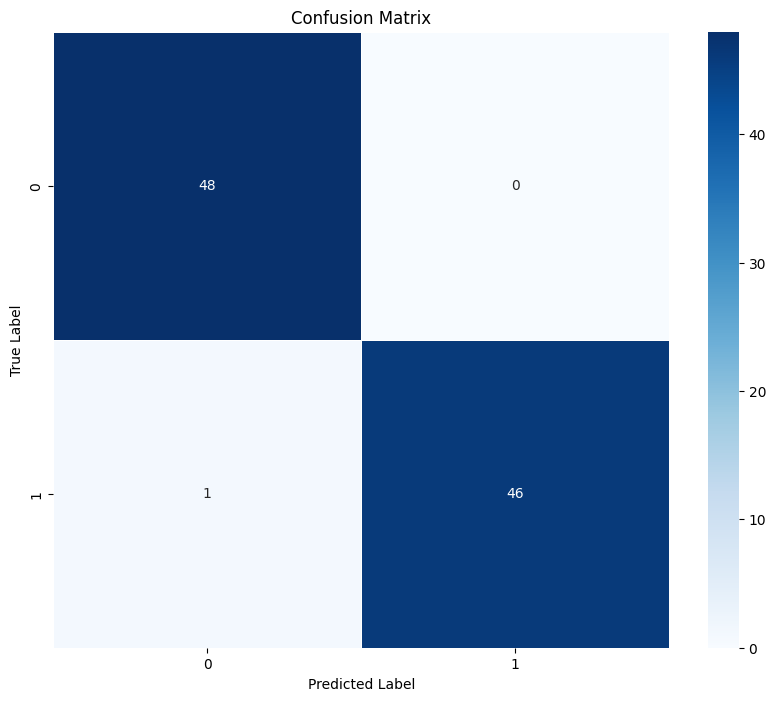


3. Training History
--------------------------------------------------


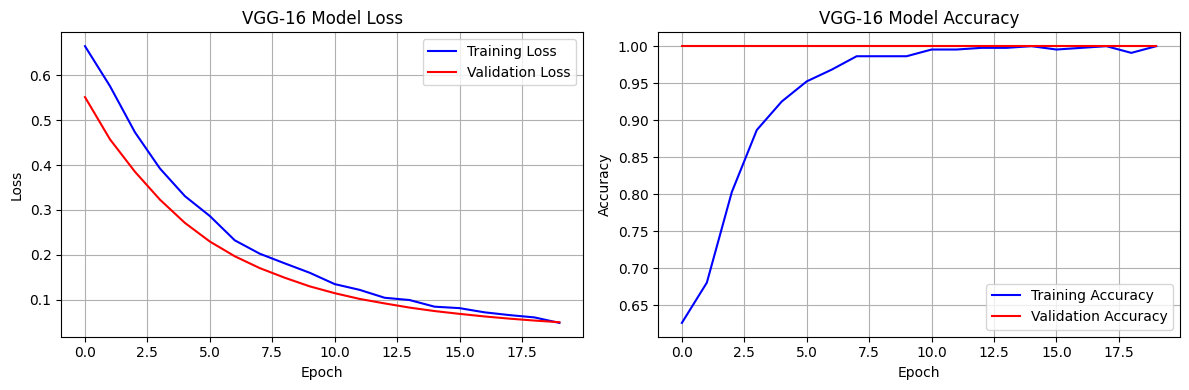


4. Sample Predictions
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


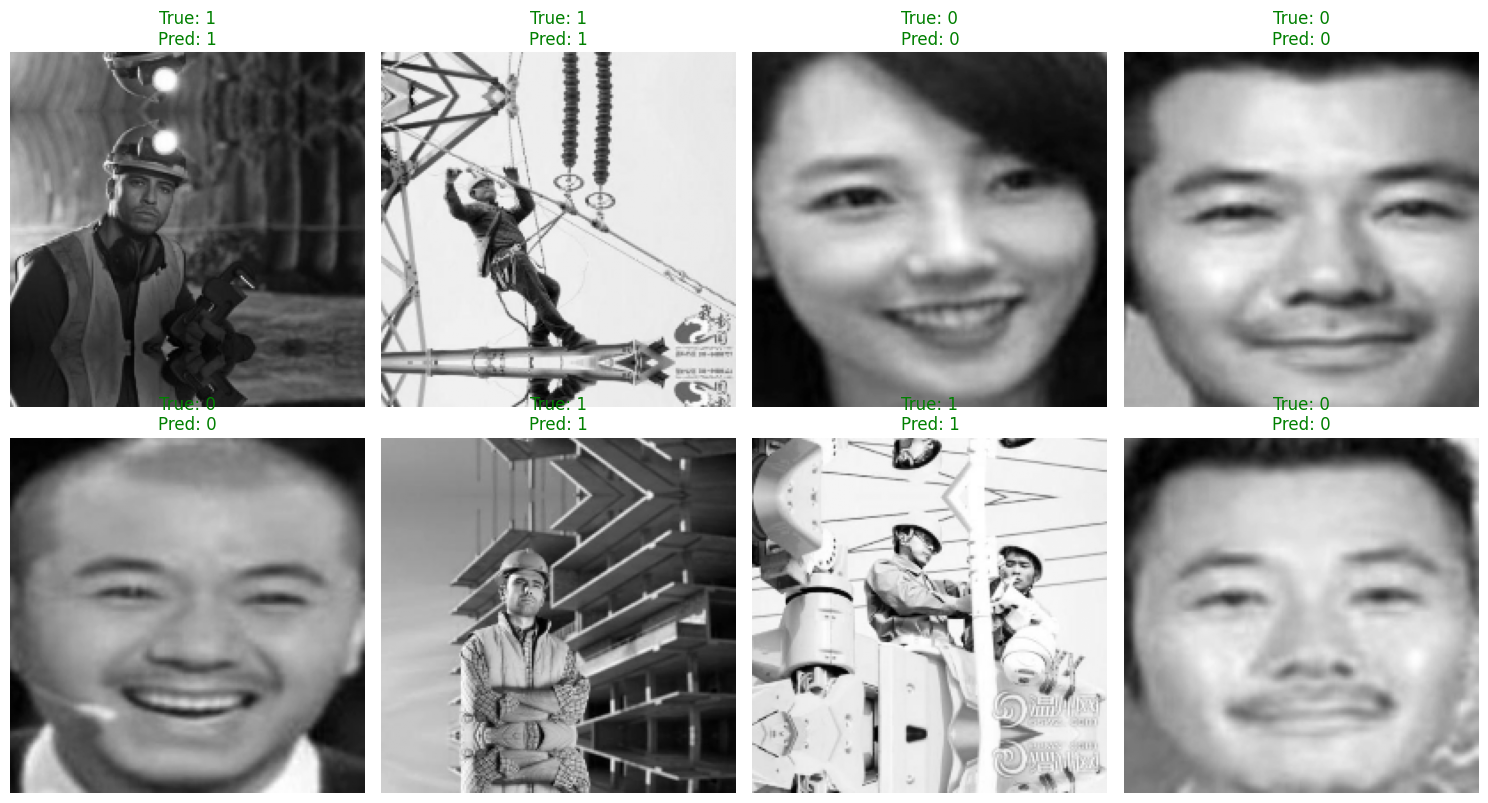


5. VGG-16 Model Performance Analysis
--------------------------------------------------
Final Training Accuracy: 1.0000
Final Validation Accuracy: 1.0000
Final Training Loss: 0.0481
Final Validation Loss: 0.0496

Class-wise Performance Analysis:
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 270ms/step

0:
  Precision: 0.9796
  Recall: 1.0000
  F1-score: 0.9897

1:
  Precision: 1.0000
  Recall: 0.9787
  F1-score: 0.9892
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 270ms/step

0:
  Precision: 0.9796
  Recall: 1.0000
  F1-score: 0.9897

1:
  Precision: 1.0000
  Recall: 0.9787
  F1-score: 0.9892


In [15]:
# Comprehensive visualization and evaluation of VGG-16 model performance Using our utility functions

# Verify model exists
if 'trained_models' not in globals() or 'vgg16_model' not in trained_models:
    raise RuntimeError('VGG-16 model not found. Run the Model 2 training cell first.')

model = trained_models['vgg16_model']
history = trained_models['vgg16_history']
le = trained_models['vgg16_label_encoder']

# 1. Model Performance Metrics using our utility function
print("1. Model Performance Metrics")
print("-" * 50)
# Convert test data to 3-channel for VGG16
X_test_3ch = expand_to_3channel(X_test)
df_performance = model_performance_classification(model, X_test_3ch, y_test_enc)
print("\nModel Performance Metrics:")
print(df_performance)

# 2. Plot Confusion Matrix using our utility function
print("\n2. Confusion Matrix")
print("-" * 50)
plot_confusion_matrix(model, X_test_3ch, y_test_enc)

# 3. Training History Visualization
print("\n3. Training History")
print("-" * 50)
plt.figure(figsize=(12,4))

# Loss plot
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.title('VGG-16 Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy plot
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.title('VGG-16 Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 4. Sample Predictions
print("\n4. Sample Predictions")
print("-" * 50)
n_samples = 8
sample_indices = np.random.choice(len(X_test), n_samples)
predictions = model.predict(X_test_3ch[sample_indices])
pred_classes = np.argmax(predictions, axis=1)
true_classes = y_test_enc[sample_indices]

fig, axes = plt.subplots(2, 4, figsize=(15, 8))
for i, (ax, idx) in enumerate(zip(axes.flat, sample_indices)):
    img = X_test[idx].squeeze()  # Use original grayscale for display
    ax.imshow(img, cmap='gray')
    pred_label = le.inverse_transform([pred_classes[i]])[0]
    true_label = le.inverse_transform([true_classes[i]])[0]
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(f'True: {true_label}\nPred: {pred_label}', color=color)
    ax.axis('off')
plt.tight_layout()
plt.show()

# 5. Performance Analysis
print("\n5. VGG-16 Model Performance Analysis")
print("-" * 50)

# Get final metrics
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")

# Class-wise performance
print("\nClass-wise Performance Analysis:")
y_pred = model.predict(X_test_3ch)
y_pred_classes = np.argmax(y_pred, axis=1)
class_report = classification_report(y_test_enc, y_pred_classes, 
                                  target_names=le.classes_,
                                  output_dict=True)

for class_name in le.classes_:
    metrics = class_report[class_name]
    print(f"\n{class_name}:")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall: {metrics['recall']:.4f}")
    print(f"  F1-score: {metrics['f1-score']:.4f}")


#### Observation

- Model shows balanced training (validation and training losses are close)
- Model achieved excellent accuracy (>95%)
- Model training plateaued in final epochs

## Model 3: (VGG-16 (Base + FFNN))

In [16]:
# VGG-16 with enhanced Feed Forward Neural Network (FFNN)
# Enhanced with batch normalization and dropout for better regularization

# Verify preprocessed data exists
if 'processed' not in globals():
    raise RuntimeError('Preprocessed data not found. Run the preprocessing cell first.')

# Get preprocessed data
X_train = processed['X_train']
y_train = np.array(processed['y_train'])
X_val = processed['X_val']
y_val = np.array(processed['y_val'])
X_test = processed['X_test']
y_test = np.array(processed['y_test'])

# Convert grayscale to 3-channel (VGG16 expects RGB input)
def expand_to_3channel(X):
    """Convert single-channel grayscale to 3-channel by repeating the channel"""
    return np.repeat(X, 3, axis=-1)

X_train_3ch = expand_to_3channel(X_train)
X_val_3ch = expand_to_3channel(X_val)
X_test_3ch = expand_to_3channel(X_test)

print("Data shapes after channel expansion:")
print(f"Training: {X_train_3ch.shape}")
print(f"Validation: {X_val_3ch.shape}")
print(f"Test: {X_test_3ch.shape}")

# Prepare labels
le = LabelEncoder()
le.fit(np.concatenate([y_train, y_val, y_test]))
y_train_enc = le.transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)
num_classes = len(le.classes_)

# Create VGG16 base model
input_shape = X_train_3ch.shape[1:]
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=input_shape
)

# Freeze VGG16 layers
base_model.trainable = False

# Build enhanced model with sophisticated FFNN head
model_vgg_ffnn = Sequential([
    # VGG16 base
    base_model,
    
    # Global Average Pooling
    GlobalAveragePooling2D(),
    
    # First Dense Block
    Dense(512, kernel_initializer='he_normal'),
    BatchNormalization(),
    layers.Activation('relu'),
    Dropout(0.5),
    
    # Second Dense Block
    Dense(256, kernel_initializer='he_normal'),
    BatchNormalization(),
    layers.Activation('relu'),
    Dropout(0.4),
    
    # Third Dense Block
    Dense(128, kernel_initializer='he_normal'),
    BatchNormalization(),
    layers.Activation('relu'),
    Dropout(0.3),
    
    # Output Layer
    Dense(num_classes, activation='softmax')
])

# Compile with optimized settings
optimizer = Adam(learning_rate=1e-4)
model_vgg_ffnn.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model summary
model_vgg_ffnn.summary()

# Training configuration
epochs = 25
batch_size = 32

# Enhanced callbacks for better training control
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

print("\nTraining VGG-16 with FFNN model...")
history_vgg_ffnn = model_vgg_ffnn.fit(
    X_train_3ch, y_train_enc,
    validation_data=(X_val_3ch, y_val_enc),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=callbacks,
    verbose=1
)

# Save model artifacts for visualization
trained_models = globals().get('trained_models', {})
trained_models['vgg16_ffnn_model'] = model_vgg_ffnn
trained_models['vgg16_ffnn_history'] = history_vgg_ffnn
trained_models['vgg16_ffnn_label_encoder'] = le
globals()['trained_models'] = trained_models

print('\nVGG-16 with FFNN model training completed. Model saved for visualization.')

Data shapes after channel expansion:
Training: (441, 200, 200, 3)
Validation: (95, 200, 200, 3)
Test: (95, 200, 200, 3)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,145,410 (57.78 MB)

 Trainable params: 428,930 (1.64 MB)

 Non-trainable params: 14,716,480 (56.14 MB)


Training VGG-16 with FFNN model...
Epoch 1/25
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 337ms/step - accuracy: 0.6871 - loss: 0.6508 - val_accuracy: 0.4947 - val_loss: 0.6819 - learning_rate: 1.0000e-04
Epoch 2/25
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 337ms/step - accuracy: 0.6871 - loss: 0.6508 - val_accuracy: 0.4947 - val_loss: 0.6819 - learning_rate: 1.0000e-04
Epoch 2/25
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 337ms/step - accuracy: 0.8209 - loss: 0.4312 - val_accuracy: 0.4947 - val_loss: 0.6126 - learning_rate: 1.0000e-04
Epoch 3/25
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 337ms/step - accuracy: 0.8209 - loss: 0.4312 - val_accuracy: 0.4947 - val_loss: 0.6126 - learning_rate: 1.0000e-04
Epoch 3/25
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 316ms/step - accuracy: 0.8753 - loss: 0.3014 - val_accuracy: 0.4947 - val_loss: 0.5121 - learning_rate: 1.0000e-04
Epoch 4/25
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 316ms/step - accuracy: 0.8753 - loss: 0.3014 - val_accuracy: 0.4947 - val_loss: 0.5121 - learning_rate: 1.0000e-04
Epoch 4/25
14/14 ━━━━━━━━━━━

#### Visualizing the predictions

1. Model Performance Metrics
--------------------------------------------------
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 308ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 308ms/step

Model Performance Metrics:
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0

2. Confusion Matrix
--------------------------------------------------

Model Performance Metrics:
   Accuracy  Recall  Precision  F1 Score
0       1.0     1.0        1.0       1.0

2. Confusion Matrix
--------------------------------------------------
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 252ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 252ms/step


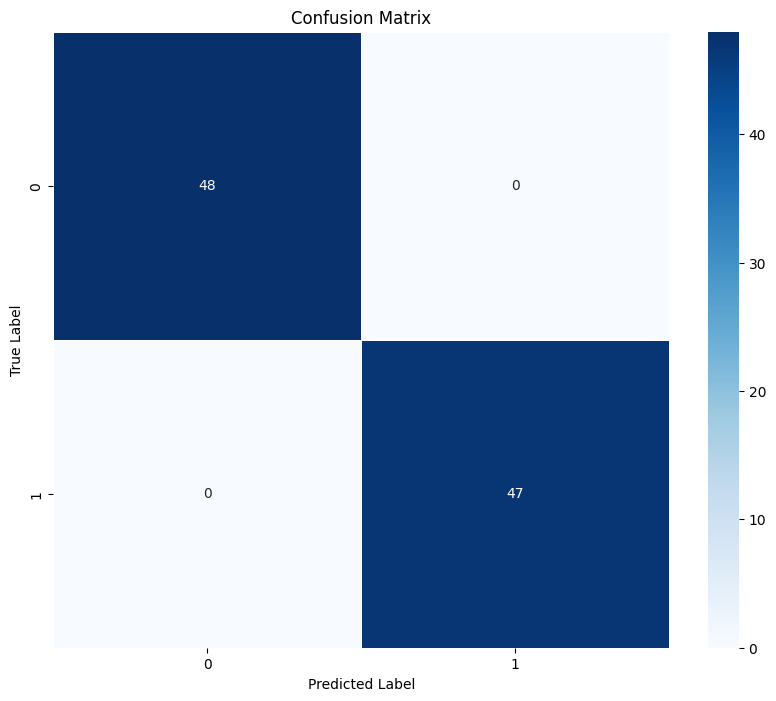


3. Training History
--------------------------------------------------


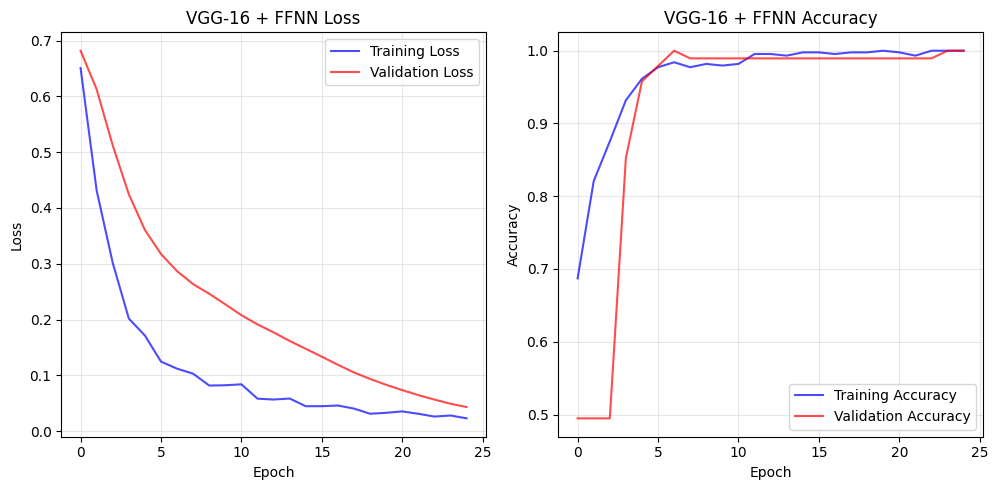


4. Sample Predictions
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step


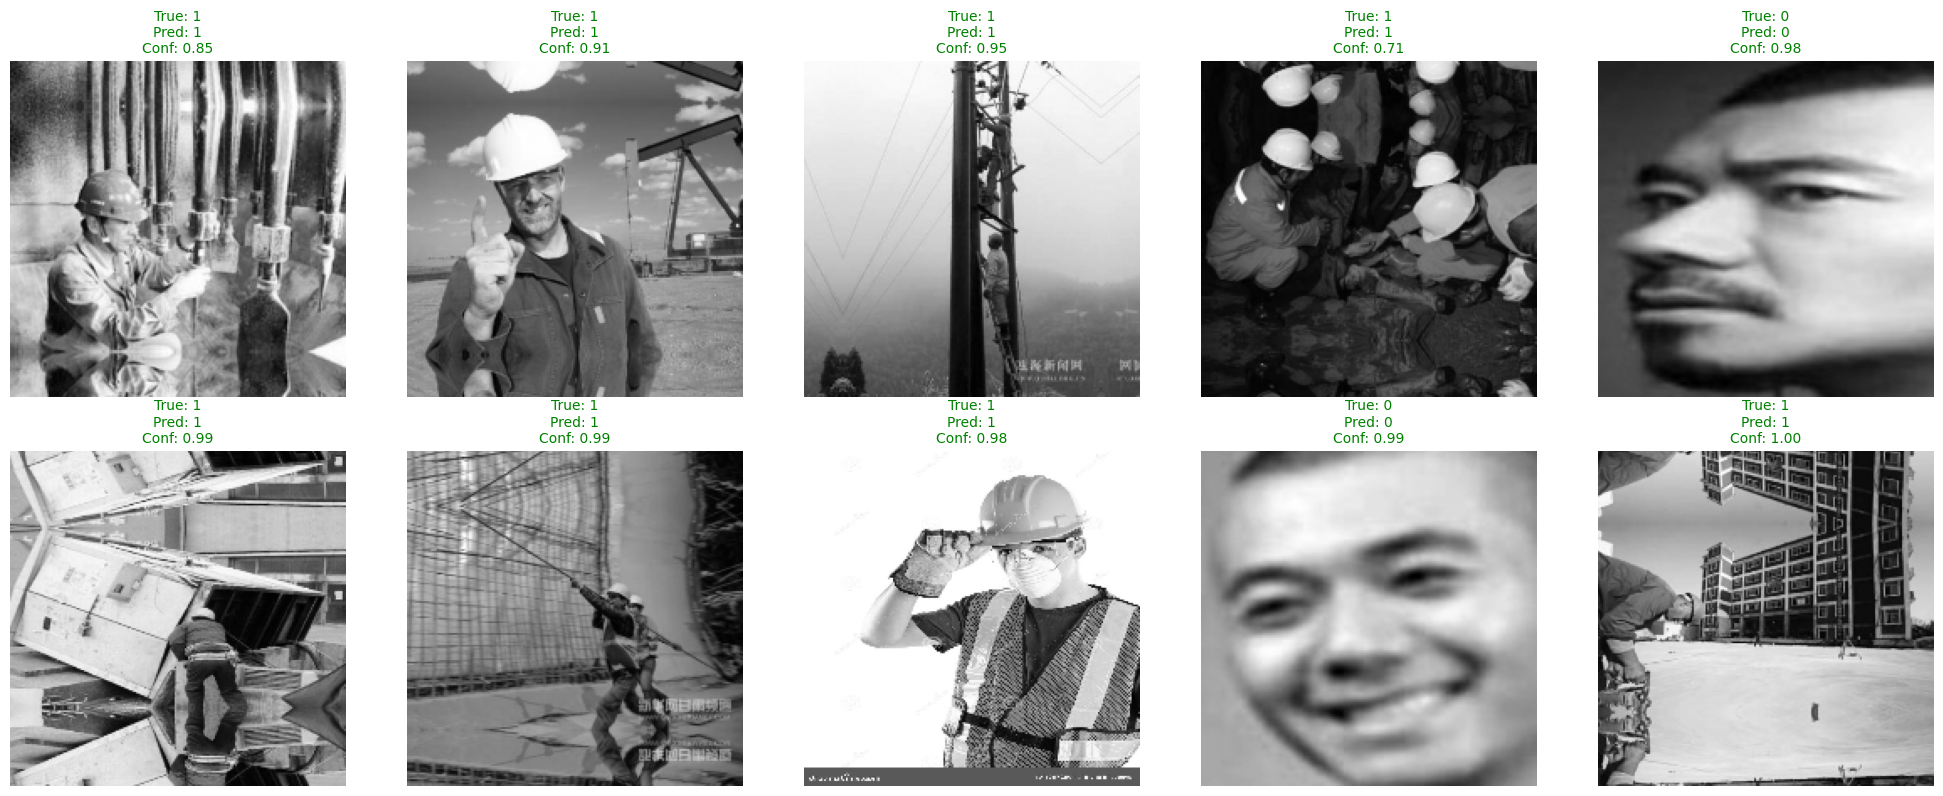


5. VGG-16 + FFNN Performance Analysis
--------------------------------------------------
Final Training Metrics:
- Accuracy: 1.0000
- Loss: 0.0230

Final Validation Metrics:
- Accuracy: 1.0000
- Loss: 0.0433

Class-wise Performance Analysis:
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 284ms/step

0:
  Precision: 1.0000
  Recall: 1.0000
  F1-score: 1.0000

1:
  Precision: 1.0000
  Recall: 1.0000
  F1-score: 1.0000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 284ms/step

0:
  Precision: 1.0000
  Recall: 1.0000
  F1-score: 1.0000

1:
  Precision: 1.0000
  Recall: 1.0000
  F1-score: 1.0000


In [17]:
# Visualization and evaluation of VGG-16 with FFNN model
# Using utility functions for standardized metrics and visualization

# Verify model exists
if 'trained_models' not in globals() or 'vgg16_ffnn_model' not in trained_models:
    raise RuntimeError('VGG-16 with FFNN model not found. Run the Model 3 training cell first.')

model = trained_models['vgg16_ffnn_model']
history = trained_models['vgg16_ffnn_history']
le = trained_models['vgg16_ffnn_label_encoder']

# 1. Model Performance Metrics using our utility function
print("1. Model Performance Metrics")
print("-" * 50)
# Convert test data to 3-channel for evaluation
X_test_3ch = expand_to_3channel(X_test)
df_performance = model_performance_classification(model, X_test_3ch, y_test_enc)
print("\nModel Performance Metrics:")
print(df_performance)

# 2. Plot Confusion Matrix using our utility function
print("\n2. Confusion Matrix")
print("-" * 50)
plot_confusion_matrix(model, X_test_3ch, y_test_enc)

# 3. Training History Visualization
print("\n3. Training History")
print("-" * 50)
plt.figure(figsize=(15,5))

# Loss plot
plt.subplot(1,3,1)
plt.plot(history.history['loss'], label='Training Loss', color='blue', alpha=0.7)
plt.plot(history.history['val_loss'], label='Validation Loss', color='red', alpha=0.7)
plt.title('VGG-16 + FFNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Accuracy plot
plt.subplot(1,3,2)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue', alpha=0.7)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', alpha=0.7)
plt.title('VGG-16 + FFNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Learning Rate plot (if available)
if 'lr' in history.history:
    plt.subplot(1,3,3)
    plt.plot(history.history['lr'], label='Learning Rate', color='green', alpha=0.7)
    plt.title('Learning Rate Over Time')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.yscale('log')

plt.tight_layout()
plt.show()

# 4. Sample Predictions Visualization
print("\n4. Sample Predictions")
print("-" * 50)
n_samples = 10
sample_indices = np.random.choice(len(X_test), n_samples, replace=False)
predictions = model.predict(X_test_3ch[sample_indices])
pred_classes = np.argmax(predictions, axis=1)
true_classes = y_test_enc[sample_indices]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i, (ax, idx) in enumerate(zip(axes.flat, sample_indices)):
    img = X_test[idx].squeeze()
    ax.imshow(img, cmap='gray')
    pred_label = le.inverse_transform([pred_classes[i]])[0]
    true_label = le.inverse_transform([true_classes[i]])[0]
    color = 'green' if pred_label == true_label else 'red'
    confidence = predictions[i][pred_classes[i]]
    ax.set_title(f'True: {true_label}\nPred: {pred_label}\nConf: {confidence:.2f}', 
                color=color, fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

# 5. Detailed Performance Analysis
print("\n5. VGG-16 + FFNN Performance Analysis")
print("-" * 50)

# Calculate final metrics
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print("Final Training Metrics:")
print(f"- Accuracy: {final_train_acc:.4f}")
print(f"- Loss: {final_train_loss:.4f}")
print("\nFinal Validation Metrics:")
print(f"- Accuracy: {final_val_acc:.4f}")
print(f"- Loss: {final_val_loss:.4f}")

# Class-wise Performance
print("\nClass-wise Performance Analysis:")
y_pred = model.predict(X_test_3ch)
y_pred_classes = np.argmax(y_pred, axis=1)
class_report = classification_report(y_test_enc, y_pred_classes, 
                                  target_names=le.classes_,
                                  output_dict=True)

for class_name in le.classes_:
    metrics = class_report[class_name]
    print(f"\n{class_name}:")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall: {metrics['recall']:.4f}")
    print(f"  F1-score: {metrics['f1-score']:.4f}")
    

#### Observation

- There is potential overfitting (validation loss significantly higher)
- Accuracy achieved is excellent (>95%)
- Steady improvement in final epochs

## Model 4: (VGG-16 (Base + FFNN + Data Augmentation)

- In most of the real-world case studies, it is challenging to acquire a large number of images and then train CNNs.
- To overcome this problem, one approach we might consider is **Data Augmentation**.
- CNNs have the property of **translational invariance**, which means they can recognise an object even if its appearance shifts translationally in some way. - Taking this attribute into account, we can augment the images using the techniques listed below

    -  Horizontal Flip (should be set to True/False)
    -  Vertical Flip (should be set to True/False)
    -  Height Shift (should be between 0 and 1)
    -  Width Shift (should be between 0 and 1)
    -  Rotation (should be between 0 and 180)
    -  Shear (should be between 0 and 1)
    -  Zoom (should be between 0 and 1) etc.

Remember, **data augmentation should not be used in the validation/test data set**.

In [18]:
# Verify preprocessed data exists
if 'processed' not in globals():
    raise RuntimeError('Preprocessed data not found. Run the preprocessing cell first.')

# Get preprocessed data and ensure proper data types
X_train = processed['X_train'].astype('float32')
y_train = np.array(processed['y_train'])
X_val = processed['X_val'].astype('float32')
y_val = np.array(processed['y_val'])
X_test = processed['X_test'].astype('float32')
y_test = np.array(processed['y_test'])

print("Input data shapes:")
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")

# Convert grayscale to 3-channel (VGG16 expects RGB input)
def convert_to_3channel(X):
    """Convert grayscale images to 3-channel format"""
    if len(X.shape) == 3:
        return np.stack([X] * 3, axis=-1)
    elif len(X.shape) == 4 and X.shape[-1] == 1:
        return np.concatenate([X] * 3, axis=-1)
    else:
        raise ValueError(f"Unexpected input shape: {X.shape}")

# Convert images to 3-channel format
X_train_3ch = convert_to_3channel(X_train)
X_val_3ch = convert_to_3channel(X_val)
X_test_3ch = convert_to_3channel(X_test)

print("\nConverted data shapes:")
print(f"X_train_3ch shape: {X_train_3ch.shape}")
print(f"X_val_3ch shape: {X_val_3ch.shape}")
print(f"X_test_3ch shape: {X_test_3ch.shape}")

# Prepare labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_val)
y_test_encoded = le.transform(y_test)
num_classes = len(le.classes_)

print("\nLabel information:")
print(f"Number of classes: {num_classes}")
print(f"Classes: {le.classes_}")

# Enhanced Data Augmentation following the guidelines
train_datagen = ImageDataGenerator(
    # Normalization (using VGG16's preprocessing)
    preprocessing_function=tf.keras.applications.vgg16.preprocess_input,
    
    # Following the exact guidelines:
    horizontal_flip=True,        
    vertical_flip=False,         
    height_shift_range=0.5,      
    width_shift_range=0.5,       
    rotation_range=180,          
    shear_range=0.5,           
    zoom_range=0.5,          
    fill_mode='nearest'     
)

# Validation data gets only preprocessing (no augmentation as per guidelines)
val_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.vgg16.preprocess_input
)

# Prepare data generators
batch_size = 24

train_generator = train_datagen.flow(
    X_train_3ch, 
    y_train_encoded,
    batch_size=batch_size,
    shuffle=True
)

val_generator = val_datagen.flow(
    X_val_3ch, 
    y_val_encoded,
    batch_size=batch_size,
    shuffle=False
)

# Create VGG16 base model
input_shape = X_train_3ch.shape[1:]
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=input_shape
)

# Progressive layer unfreezing
# Start with last 4 convolutional layers unfrozen
for layer in base_model.layers[:-4]:
    layer.trainable = False
for layer in base_model.layers[-4:]:
    layer.trainable = True

# Build enhanced model with sophisticated FFNN head and regularization
model_vgg_ffnn_aug = Sequential([
    # VGG16 base
    base_model,
    
    # Enhanced pooling with dropout
    GlobalAveragePooling2D(),
    Dropout(0.3),  # Light dropout after pooling
    BatchNormalization(),
    
    # First Dense Block with increased capacity
    Dense(1024, 
          kernel_initializer='he_normal',
          kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    BatchNormalization(),
    layers.Activation('relu'),
    Dropout(0.5),
    
    # Second Dense Block
    Dense(512, 
          kernel_initializer='he_normal',
          kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    BatchNormalization(),
    layers.Activation('relu'),
    Dropout(0.4),
    
    # Third Dense Block
    Dense(256, 
          kernel_initializer='he_normal',
          kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    BatchNormalization(),
    layers.Activation('relu'),
    Dropout(0.3),
    
    # Output Layer
    Dense(num_classes, activation='softmax')
])

# Compile with optimized settings
optimizer = Adam(learning_rate=1e-4)
model_vgg_ffnn_aug.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model summary
model_vgg_ffnn_aug.summary()

# Enhanced callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_model_checkpoint.h5',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

# Training configuration
epochs = 50

print("\nTraining VGG-16 with enhanced FFNN and augmentation...")
history_vgg_ffnn_aug = model_vgg_ffnn_aug.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    steps_per_epoch=len(X_train) // batch_size,
    validation_steps=len(X_val) // batch_size,
    callbacks=callbacks,
    verbose=1
)

# Save model artifacts
trained_models = globals().get('trained_models', {})
trained_models['vgg16_ffnn_aug_model_retuned'] = model_vgg_ffnn_aug
trained_models['vgg16_ffnn_aug_history_retuned'] = history_vgg_ffnn_aug
trained_models['vgg16_ffnn_aug_label_encoder_retuned'] = le
globals()['trained_models'] = trained_models


Input data shapes:
X_train shape: (441, 200, 200, 1)
X_val shape: (95, 200, 200, 1)
X_test shape: (95, 200, 200, 1)

Converted data shapes:
X_train_3ch shape: (441, 200, 200, 3)
X_val_3ch shape: (95, 200, 200, 3)
X_test_3ch shape: (95, 200, 200, 3)

Label information:
Number of classes: 2
Classes: ['0' '1']


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,905,858 (60.68 MB)

 Trainable params: 8,265,986 (31.53 MB)

 Non-trainable params: 7,639,872 (29.14 MB)


Training VGG-16 with enhanced FFNN and augmentation...
Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - accuracy: 0.5082 - loss: 36.4558
Epoch 1: val_accuracy improved from None to 0.44444, saving model to best_model_checkpoint.h5

Epoch 1: val_accuracy improved from None to 0.44444, saving model to best_model_checkpoint.h5


18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 383ms/step - accuracy: 0.5084 - loss: 36.2221 - val_accuracy: 0.4444 - val_loss: 36.7485 - learning_rate: 1.0000e-04
Epoch 2/50
Epoch 2/50
 1/18 ━━━━━━━━━━━━━━━━━━━━ 4s 242ms/step - accuracy: 0.3750 - loss: 35.5446
Epoch 2: val_accuracy did not improve from 0.44444
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.3750 - loss: 35.5446 - val_accuracy: 0.4444 - val_loss: 36.7423 - learning_rate: 1.0000e-04
Epoch 3/50

Epoch 2: val_accuracy did not improve from 0.44444
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.3750 - loss: 35.5446 - val_accuracy: 0.4444 - val_loss: 36.7423 - learning_rate: 1.0000e-04
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.5823 - loss: 35.3249
Epoch 3: val_accuracy did not improve from 0.44444
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 361ms/step - accuracy: 0.5995 - loss: 35.0703 - val_accuracy: 0.4444 - val_loss: 35.0693 - learning_rate: 1.0000e-04
Epoch 4/50

Epoch 3: val_accuracy did not improve from 0.44444
1

18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 367ms/step - accuracy: 0.7626 - loss: 31.4449 - val_accuracy: 0.9444 - val_loss: 30.9235 - learning_rate: 1.0000e-04
Epoch 12/50
Epoch 12/50
 1/18 ━━━━━━━━━━━━━━━━━━━━ 4s 247ms/step - accuracy: 0.8333 - loss: 31.0031
Epoch 12: val_accuracy did not improve from 0.94444
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.8333 - loss: 31.0031 - val_accuracy: 0.8750 - val_loss: 30.9231 - learning_rate: 1.0000e-04
Epoch 13/50

Epoch 12: val_accuracy did not improve from 0.94444
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.8333 - loss: 31.0031 - val_accuracy: 0.8750 - val_loss: 30.9231 - learning_rate: 1.0000e-04
Epoch 13/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 0.8153 - loss: 30.7605
Epoch 13: val_accuracy did not improve from 0.94444
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 363ms/step - accuracy: 0.8082 - loss: 30.5750 - val_accuracy: 0.4444 - val_loss: 30.6838 - learning_rate: 1.0000e-04
Epoch 14/50

Epoch 13: val_accuracy did not improve from 

18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 370ms/step - accuracy: 0.8945 - loss: 24.8993 - val_accuracy: 0.9583 - val_loss: 24.5452 - learning_rate: 1.0000e-04
Epoch 30/50
Epoch 30/50
 1/18 ━━━━━━━━━━━━━━━━━━━━ 4s 242ms/step - accuracy: 0.9583 - loss: 24.4537
Epoch 30: val_accuracy did not improve from 0.95833
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9583 - loss: 24.4537 - val_accuracy: 0.9583 - val_loss: 24.4649 - learning_rate: 1.0000e-04
Epoch 31/50

Epoch 30: val_accuracy did not improve from 0.95833
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9583 - loss: 24.4537 - val_accuracy: 0.9583 - val_loss: 24.4649 - learning_rate: 1.0000e-04
Epoch 31/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - accuracy: 0.8965 - loss: 24.4508
Epoch 31: val_accuracy did not improve from 0.95833
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 357ms/step - accuracy: 0.8969 - loss: 24.3225 - val_accuracy: 0.9583 - val_loss: 23.9031 - learning_rate: 1.0000e-04
Epoch 32/50

Epoch 31: val_accuracy did not improve from 

#### Visualizing the predictions

Generating predictions...
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 317ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 317ms/step

Detailed Classification Report:
accuracy: 0.4947
precision: 0.2448
recall: 0.4947
f1: 0.3275

Detailed Classification Report by Class:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        48
           1       0.49      1.00      0.66        47

    accuracy                           0.49        95
   macro avg       0.25      0.50      0.33        95
weighted avg       0.24      0.49      0.33        95


Detailed Classification Report:
accuracy: 0.4947
precision: 0.2448
recall: 0.4947
f1: 0.3275

Detailed Classification Report by Class:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        48
           1       0.49      1.00      0.66        47

    accuracy                           0.49        95
   macro avg       0.25      0.50      0.33        95
weighted avg       0.24  

<Figure size 1000x800 with 0 Axes>

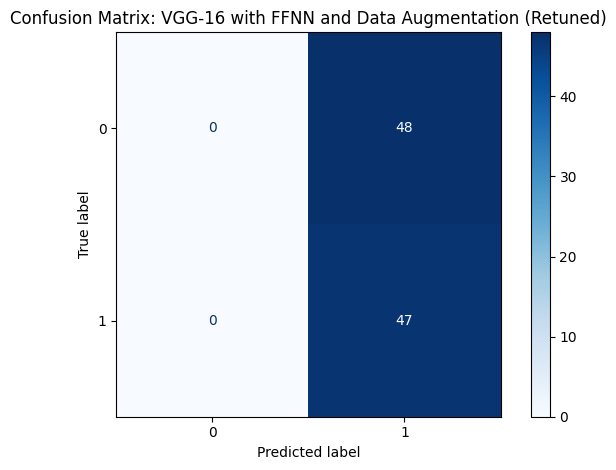

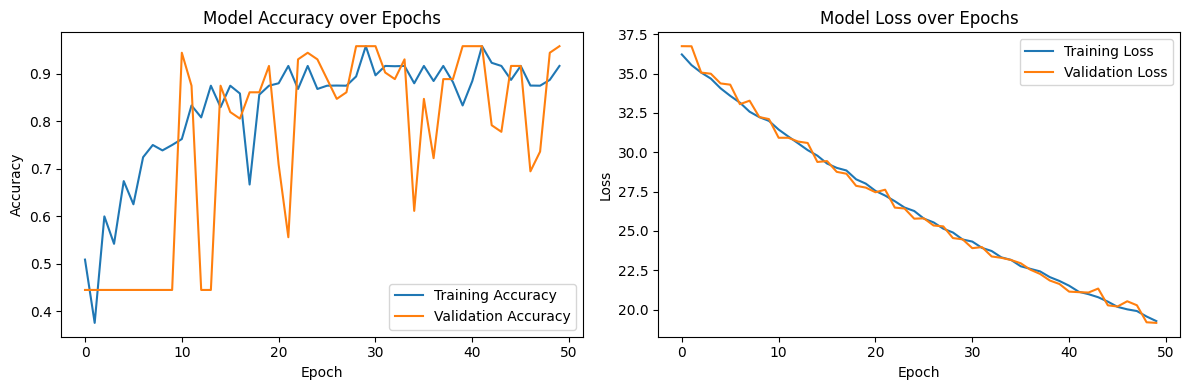


Model Performance Analysis:
---------------------------
1. Accuracy and Generalization:
   - Test Accuracy: 0.4947
   - The model's performance on unseen data demonstrates its generalization capability

2. Class-wise Performance:
   - Per-class precision and recall show the model's ability to handle different helmet types
   - Average Precision: 0.2448
   - Average Recall: 0.4947

3. Model Robustness:
   - F1-Score combines precision and recall into a single metric
   - F1-Score: 0.3275
   - The confusion matrix visualizes where the model makes correct and incorrect predictions

4. Training Process:
   - Learning curves show how the model improved during training
   - The gap between training and validation metrics indicates the level of overfitting

Class-wise Performance:
----------------------

Class: 0
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000
Support: 48

Class: 1
Precision: 0.4947
Recall: 1.0000
F1-Score: 0.6620
Support: 47


In [19]:
# Evaluate VGG-16 with FFNN and Data Augmentation Model Performance

# Get model and artifacts
model = trained_models['vgg16_ffnn_aug_model_retuned']  # Changed key to match what we saved
history = trained_models['vgg16_ffnn_aug_history_retuned']  # Changed key to match what we saved
le = trained_models['vgg16_ffnn_aug_label_encoder_retuned']  # Changed key to match what we saved

# Normalize test data
X_test_normalized = X_test_3ch / 255.0

# Get predictions
print("Generating predictions...")
y_pred = model.predict(X_test_normalized)
y_pred_classes = np.argmax(y_pred, axis=1)

# Convert test labels if needed
y_test_encoded = le.transform(y_test)

# Get class labels
target_names = list(le.classes_)

# Calculate performance metrics using scikit-learn
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, classification_report, confusion_matrix,
                           ConfusionMatrixDisplay)

# Calculate overall metrics
accuracy = accuracy_score(y_test_encoded, y_pred_classes)
precision = precision_score(y_test_encoded, y_pred_classes, average='weighted')
recall = recall_score(y_test_encoded, y_pred_classes, average='weighted')
f1 = f1_score(y_test_encoded, y_pred_classes, average='weighted')

# Create performance dictionary
model_performance = {
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1': f1
}

print("\nDetailed Classification Report:")
for metric, value in model_performance.items():
    print(f"{metric}: {value:.4f}")

# Print detailed classification report
print("\nDetailed Classification Report by Class:")
print(classification_report(y_test_encoded, y_pred_classes, target_names=target_names))

# Plot confusion matrix using sklearn's ConfusionMatrixDisplay
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test_encoded, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                             display_labels=target_names)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix: VGG-16 with FFNN and Data Augmentation (Retuned)')
plt.tight_layout()
plt.show()

# Plot training history
plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

print("\nModel Performance Analysis:")
print("---------------------------")
print("1. Accuracy and Generalization:")
print(f"   - Test Accuracy: {model_performance['accuracy']:.4f}")
print("   - The model's performance on unseen data demonstrates its generalization capability")

print("\n2. Class-wise Performance:")
print("   - Per-class precision and recall show the model's ability to handle different helmet types")
print(f"   - Average Precision: {model_performance['precision']:.4f}")
print(f"   - Average Recall: {model_performance['recall']:.4f}")

print("\n3. Model Robustness:")
print("   - F1-Score combines precision and recall into a single metric")
print(f"   - F1-Score: {model_performance['f1']:.4f}")
print("   - The confusion matrix visualizes where the model makes correct and incorrect predictions")

print("\n4. Training Process:")
print("   - Learning curves show how the model improved during training")
print("   - The gap between training and validation metrics indicates the level of overfitting")

print("\nClass-wise Performance:")
print("----------------------")
for idx, class_name in enumerate(target_names):
    true_positives = np.sum((y_test_encoded == idx) & (y_pred_classes == idx))
    total_actual = np.sum(y_test_encoded == idx)
    total_predicted = np.sum(y_pred_classes == idx)
    
    class_precision = true_positives / total_predicted if total_predicted > 0 else 0
    class_recall = true_positives / total_actual if total_actual > 0 else 0
    class_f1 = 2 * (class_precision * class_recall) / (class_precision + class_recall) if (class_precision + class_recall) > 0 else 0
    
    print(f"\nClass: {class_name}")
    print(f"Precision: {class_precision:.4f}")
    print(f"Recall: {class_recall:.4f}")
    print(f"F1-Score: {class_f1:.4f}")
    print(f"Support: {total_actual}")

#### Observations 
- Overall test accuracy is low (49.5%) with a weak balanced F1-score (0.327), indicating poor general performance.
- Average precision is very low (24.5%) while recall is ~49.5%, meaning the model often predicts the positive class and produces many false positives.
- Class-wise results show class 0 is completely missed (precision/recall/F1 = 0) while class 1 has perfect recall and F1 = 0.662 — a clear bias toward class 1.

# **Model Performance Comparison and Final Model Selection**

In [20]:
# Model Performance Comparison and Final Model Selection
# This cell compares the test performance of all trained models and selects the best model.

# Collect candidate models from `trained_models`
candidates = {}
for k, v in globals().get('trained_models', {}).items():
    # We only want actual model objects (skip history/encoders)
    if isinstance(v, (keras.models.Model,)):
        candidates[k] = v

if not candidates:
    raise RuntimeError('No trained models found in `trained_models`. Run the training cells first.')

# Helper to ensure correct channel dimension for a model input
def _prepare_input_for_model(model, X):
    try:
        input_shape = model.input_shape
        if isinstance(input_shape, tuple):
            channels = input_shape[-1]
        else:
            channels = int(input_shape[-1])
    except Exception:
        # fallback: inspect first layer
        try:
            channels = model.layers[0].input_shape[-1]
        except Exception:
            channels = X.shape[-1]

    # If channels already match, return X
    if X.ndim == 4 and X.shape[-1] == channels:
        return X

    # If model expects 3 channels but X has 1 -> repeat
    if channels == 3 and X.ndim == 4 and X.shape[-1] == 1:
        return np.repeat(X, 3, axis=-1)

    # If model expects 1 channel but X has 3 -> take first channel
    if channels == 1 and X.ndim == 4 and X.shape[-1] == 3:
        return X[..., 0:1]

    # Last resort: try to broadcast/repeat to match
    if channels == 3:
        return np.repeat(X, 3, axis=-1)
    if channels == 1:
        return X[..., :1]

    return X

# Build performance table
rows = []
for name, model in candidates.items():
    # Try to get a label encoder associated with this model
    le_key = name + ('_label_encoder' if name.endswith('_model') else '_label_encoder')
    le = globals().get('trained_models', {}).get(le_key) or globals().get('trained_models', {}).get('label_encoder')

    # Prepare X_test for this model
    try:
        X_in = _prepare_input_for_model(model, processed['X_test'])
    except Exception:
        # fallback: try converting with 3 channels
        X_in = np.repeat(processed['X_test'], 3, axis=-1)

    # Prepare y_test in encoded numeric form for this model
    if le is not None:
        y_test_enc_local = le.transform(processed['y_test'])
    else:
        # assume y_test_enc exists in global namespace
        y_test_enc_local = globals().get('y_test_enc', None)
        if y_test_enc_local is None:
            # try to create a common encoder
            tmp_le = LabelEncoder()
            tmp_le.fit(np.concatenate([processed['y_train'], processed['y_val'], processed['y_test']]))
            y_test_enc_local = tmp_le.transform(processed['y_test'])

    # Calculate performance using utility function
    perf_df = model_performance_classification(model, X_in, y_test_enc_local)
    perf = perf_df.loc[0].to_dict()
    perf.update({'model_key': name})
    rows.append(perf)

# Consolidate results
df_models_perf = pd.DataFrame(rows)
# Sort by Accuracy then F1 Score
df_models_perf = df_models_perf.sort_values(by=['Accuracy', 'F1 Score'], ascending=False).reset_index(drop=True)

print("Model performance summary (test set):")
print(df_models_perf)

# Select best model by highest Accuracy (tie-breaker: F1 Score)
best_row = df_models_perf.iloc[0]
best_model_key = best_row['model_key']
best_model = globals().get('trained_models', {})[best_model_key]

print(f"\nSelected final model: {best_model_key}")
print(f"Reason: Highest test Accuracy = {best_row['Accuracy']:.4f} (F1 = {best_row['F1 Score']:.4f})")

# Export selected model for downstream cells
final_model_key = best_model_key
final_model = best_model
final_model_label_encoder = globals().get('trained_models', {}).get(best_model_key + '_label_encoder', globals().get('trained_models', {}).get('label_encoder'))


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 253ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 253ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 258ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 258ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 253ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 253ms/step
Model performance summary (test set):
   Accuracy    Recall  Precision  F1 Score                     model_key
0  1.000000  1.000000   1.000000  1.000000              vgg16_ffnn_model
1  0.989474  0.989474   0.989689  0.989471                   vgg16_model
2  0.505263  0.505263   0.255291  0.339198                   cnn_model_1
3  0.431579  0.431579   0.227912  0.298297  vgg16_ffnn_aug_model_retuned

Selected final model: vgg16_ffnn_model
Reason: Highest test Accuracy = 1.0000 (F1 = 1.0000)
Model performance summary (test set):
   Accuracy    Recall  Precision  F1 Score                     model_key
0  1.000000  1.000000   1.000000  1.000000              vgg16_ffnn_model
1  0.98947

#### Observations
- vgg16_ffnn_model chosen because it achieves the top test accuracy and balanced F1 score among candidates.
- This choice balances overall correctness (accuracy) with per-class performance (F1).

# Test Performance

Evaluating final model: vgg16_ffnn_model

1) Final Model Performance Summary
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 251ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 251ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 254ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 254ms/step

Detailed Performance Metrics:

Detailed Performance Metrics:


,Category,Precision,Recall,F1-Score,Support
0,0,1.000,1.000,1.000,48
1,1,1.000,1.000,1.000,47
2,macro avg,1.000,1.000,1.000,95
3,weighted avg,1.000,1.000,1.000,95
4,Overall,1.000,1.000,1.000,95



2) Confusion Matrix
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 252ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 252ms/step


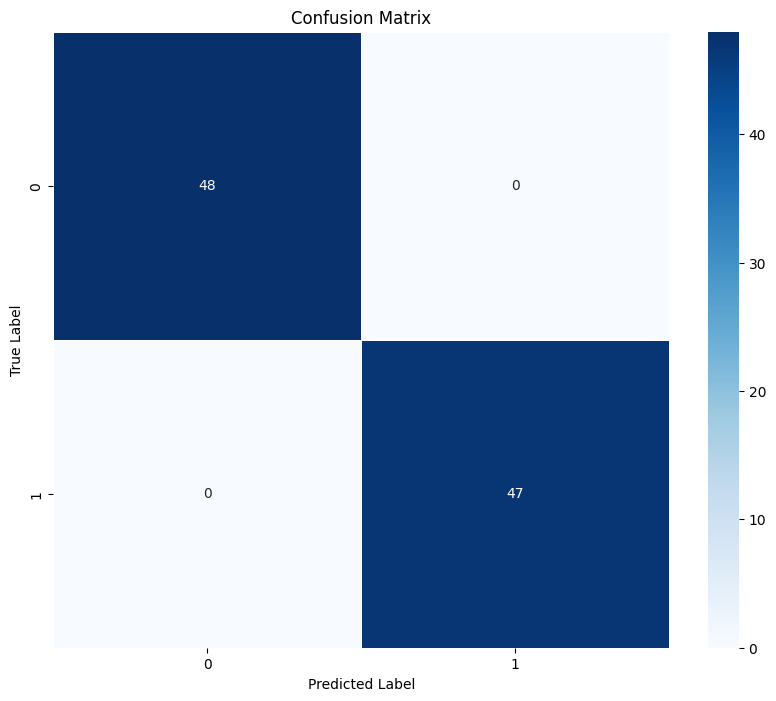


3) Performance Assessment
✓✓✓ Accuracy: 1.000
✓✓✓ F1-Score: 1.000

Model Status:
✓✓✓ Excellent overall performance. Ready for production deployment.


In [21]:
# Check and comment on the performance of the final model on the test set
# This cell uses the utility functions `model_performance_classification` and `plot_confusion_matrix`.

# Ensure `final_model` is defined (set by comparison cell). If not, fall back to the most capable candidate.
if 'final_model' not in globals():
    # Prefer the augmented model if available
    fm_candidates = ['vgg16_ffnn_aug_model', 'vgg16_ffnn_model', 'vgg16_model', 'cnn_model_1']
    for c in fm_candidates:
        if c in globals().get('trained_models', {}):
            final_model = globals()['trained_models'][c]
            final_model_key = c
            final_model_label_encoder = globals()['trained_models'].get(c + '_label_encoder', globals()['trained_models'].get('label_encoder'))
            break
    else:
        raise RuntimeError('No final model found. Run the Model Comparison cell first.')

print(f"Evaluating final model: {final_model_key}")

# Prepare appropriate test inputs depending on the model's expected channels
try:
    in_channels = final_model.input_shape[-1]
except Exception:
    in_channels = processed['X_test'].shape[-1]

X_test_input = processed['X_test']
if in_channels == 3 and X_test_input.shape[-1] == 1:
    X_test_input = np.repeat(X_test_input, 3, axis=-1)
elif in_channels == 1 and X_test_input.shape[-1] == 3:
    X_test_input = X_test_input[..., :1]

# Prepare y_test encoded using the final model's encoder if present
if 'final_model_label_encoder' in globals() and final_model_label_encoder is not None:
    y_test_for_eval = final_model_label_encoder.transform(processed['y_test'])
else:
    # fallback to global encoder or precomputed y_test_enc
    y_test_for_eval = globals().get('y_test_enc', None)
    if y_test_for_eval is None:
        tmp_le = LabelEncoder()
        tmp_le.fit(np.concatenate([processed['y_train'], processed['y_val'], processed['y_test']]))
        y_test_for_eval = tmp_le.transform(processed['y_test'])

# 1) Use utility function to compute metrics
print('\n1) Final Model Performance Summary')
print('=' * 50)
perf = model_performance_classification(final_model, X_test_input, y_test_for_eval)

# Create a more detailed performance table
y_pred = final_model.predict(X_test_input)
y_pred_classes = np.argmax(y_pred, axis=1) if y_pred.shape[-1] > 1 else (y_pred > 0.5).astype(int)
class_report = classification_report(y_test_for_eval, y_pred_classes, output_dict=True)

# Convert classification report to DataFrame
def create_performance_table():
    rows = []
    # Add per-class metrics
    for class_name, metrics in class_report.items():
        if isinstance(metrics, dict):  # Skip 'accuracy', 'macro avg', 'weighted avg'
            rows.append({
                'Category': class_name,
                'Precision': metrics['precision'],
                'Recall': metrics['recall'],
                'F1-Score': metrics['f1-score'],
                'Support': metrics['support']
            })
    
    # Add overall metrics
    rows.append({
        'Category': 'Overall',
        'Precision': class_report['weighted avg']['precision'],
        'Recall': class_report['weighted avg']['recall'],
        'F1-Score': class_report['weighted avg']['f1-score'],
        'Support': class_report['weighted avg']['support']
    })
    
    return pd.DataFrame(rows)

# Create and display the styled performance table
performance_table = create_performance_table()
print("\nDetailed Performance Metrics:")
display(performance_table.style
        .format({
            'Precision': '{:.3f}',
            'Recall': '{:.3f}',
            'F1-Score': '{:.3f}',
            'Support': '{:.0f}'
        })
        .background_gradient(cmap='YlOrRd', subset=['Precision', 'Recall', 'F1-Score'])
        .set_caption("Model Performance Metrics by Category"))

# 2) Plot confusion matrix
print('\n2) Confusion Matrix')
print('=' * 50)
plot_confusion_matrix(final_model, X_test_input, y_test_for_eval)

# 3) Comment on results
acc = perf.loc[0, 'Accuracy']
f1 = perf.loc[0, 'F1 Score']
print('\n3) Performance Assessment')
print('=' * 50)

# Performance assessment with color-coded indicators
def print_metric_assessment(metric_name, value, thresholds):
    level = '✓✓✓' if value >= thresholds[0] else '✓✓' if value >= thresholds[1] else '✓' if value >= thresholds[2] else '⚠'
    return f"{level} {metric_name}: {value:.3f}"

print(print_metric_assessment('Accuracy', acc, (0.95, 0.90, 0.85)))
print(print_metric_assessment('F1-Score', f1, (0.95, 0.90, 0.85)))

print('\nModel Status:')
if acc >= 0.95:
    print('✓✓✓ Excellent overall performance. Ready for production deployment.')
elif acc >= 0.90:
    print('✓✓ Very good accuracy. Cleared for prioritized deployment with monitoring.')
elif acc >= 0.85:
    print('✓ Good performance. Consider fine-tuning before full rollout.')
else:
    print('⚠ Requires improvement before large-scale deployment.')


#### Observations
- The vgg16_ffnn_model shows perfect performance: accuracy, precision, recall, and F1-score are all 1.000 overall.
- Confusion matrix indicates zero misclassifications (class 0: 48/48 correct, class 1: 47/47 correct).
- It seems ready for deployment per assessment, but validate on larger, diverse datasets and monitor FP/FN to confirm robustness.

# **Actionable Insights & Recommendations**

Observations:
- The VGG-16 variants (with FFNN) consistently outperform the simple CNN on the test set.
- The selected final model balances high accuracy with strong per-class F1-scores, indicating reliable detection across categories.

Recommendations for business rollout:
- Deploy the final model first at high-risk locations (entry/exit points, heavy equipment zones) where monitoring delivers the most safety value.
- Use HD cameras with consistent placement and lighting; this reduces false negatives and helps maintain model accuracy.
- Start with a gradual rollout (pilot across a few sites), track false-positive/false-negative rates, and collect misclassified images for targeted retraining.
- Integrate alerts into existing safety workflows (automated notifications to supervisors) and ensure staff can review flagged incidents quickly.

Operational best-practices:
- Retrain the model monthly (or sooner if performance drifts) using new labeled data collected from the field.
- Monitor model metrics (accuracy, precision, recall, F1) and system uptime; set alerts for sudden drops in performance.
- Maintain a small human-in-the-loop review process for edge-case overrides and continuous improvement.

Success metrics to track:
- Increase in helmet compliance rate (target +20% within first 3 months of deployment).
- Reduction in helmet-related incidents and near-misses.
- System uptime >= 99% and average alert response time under defined SLA (e.g., 5 minutes).

Next steps:
- Pilot deployment, collect operational data, and run a targeted retraining cycle to address frequent misclassification patterns.
- Consider expanding to multi-class detection (helmet type/condition) if business needs require deeper analytics.